<a href="https://colab.research.google.com/github/rishik-dev/Decision_Tree_Regression/blob/main/AdaBoost_and_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('brca.csv')
print(df.head)

<bound method NDFrame.head of      Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0             1         13.540           14.36             87.46        566.3   
1             2         13.080           15.71             85.63        520.0   
2             3          9.504           12.44             60.34        273.9   
3             4         13.030           18.42             82.61        523.8   
4             5          8.196           16.84             51.71        201.9   
..          ...            ...             ...               ...          ...   
564         565         20.920           25.09            143.00       1347.0   
565         566         21.560           22.39            142.00       1479.0   
566         567         20.130           28.25            131.20       1261.0   
567         568         16.600           28.08            108.30        858.1   
568         569         20.600           29.33            140.10       1265.0  

In [ ]:
X = df['x.concave_pts_mean']
y = df['x.concave_pts_worst']

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
model = AdaBoostRegressor()

In [ ]:
model.fit(X_train.values.reshape(-1,1),y_train)

AdaBoostRegressor()

In [ ]:
model.predict(X_test.values.reshape(-1,1))

array([0.08572793, 0.07937771, 0.04597656, 0.11476448, 0.15221193,
       0.14310925, 0.11476448, 0.08295803, 0.19831597, 0.04517111,
       0.08295803, 0.07797689, 0.14882485, 0.21265167, 0.19831597,
       0.01507357, 0.07797689, 0.01507357, 0.05821974, 0.19791125,
       0.08295803, 0.07797689, 0.16105907, 0.08295803, 0.02048241,
       0.01507357, 0.1873925 , 0.06394752, 0.07797689, 0.11476448,
       0.11411846, 0.031192  , 0.02048241, 0.08295803, 0.21265167,
       0.04765348, 0.1158617 , 0.21185432, 0.08295803, 0.19791125,
       0.04765348, 0.1158617 , 0.02048241, 0.19501303, 0.21185432,
       0.04517111, 0.11414312, 0.21185432, 0.07797689, 0.07797689,
       0.08295803, 0.07797689, 0.04765348, 0.08295803, 0.10894736,
       0.08295803, 0.02048241, 0.10894736, 0.04517111, 0.21185432,
       0.0810196 , 0.19501303, 0.04597656, 0.07797689, 0.11476448,
       0.11411846, 0.04765348, 0.07797689, 0.06394752, 0.08295803,
       0.07849132, 0.08295803, 0.14310925, 0.07797689, 0.08295

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error for XGBoost model: {mse}")

Mean Squared Error for XGBoost model: 176.13926696777344


In [ ]:
#  XG BOOST ALGORITHMN

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('adult.csv')
print(df)

       age workclass  fnlwgt     education  education.num      marital.status  \
0       90         ?   77053       HS-grad              9             Widowed   
1       82   Private  132870       HS-grad              9             Widowed   
2       66         ?  186061  Some-college             10             Widowed   
3       54   Private  140359       7th-8th              4            Divorced   
4       41   Private  264663  Some-college             10           Separated   
...    ...       ...     ...           ...            ...                 ...   
32556   22   Private  310152  Some-college             10       Never-married   
32557   27   Private  257302    Assoc-acdm             12  Married-civ-spouse   
32558   40   Private  154374       HS-grad              9  Married-civ-spouse   
32559   58   Private  151910       HS-grad              9             Widowed   
32560   22   Private  201490       HS-grad              9       Never-married   

              occupation   

In [ ]:
X = df['education']
y = df['age']

In [40]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [41]:
X_train_encoded = pd.get_dummies(X_train, prefix='education')
model = XGBRegressor()
model.fit(X_train_encoded, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
#THIS ERROR COMES IF I DO NOT PERFORM ENCODING
model = XGBRegressor()
model.fit(X_train , y_train)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:education: object

In [42]:
education_test_dummies = pd.get_dummies(X_test, prefix='education')
X_test_processed = education_test_dummies.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)
predictions = model.predict(X_test_processed)
print("Sample Predictions:")
print(predictions[:10])

Sample Predictions:
[38.907696 35.74343  38.75124  35.74343  38.75124  35.74343  35.74343
 38.907696 35.74343  38.907696]


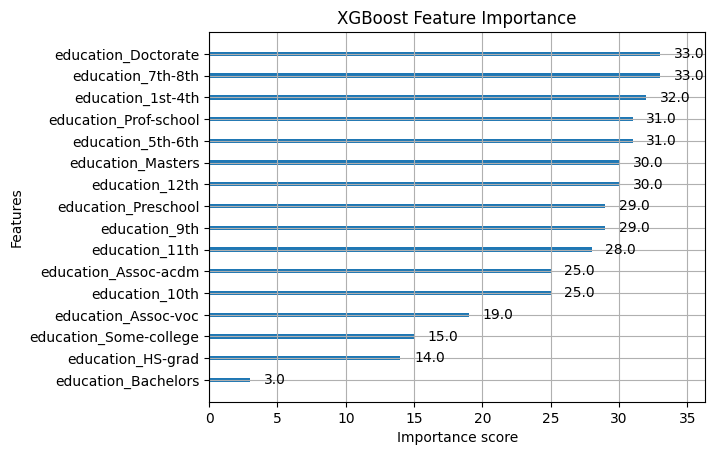

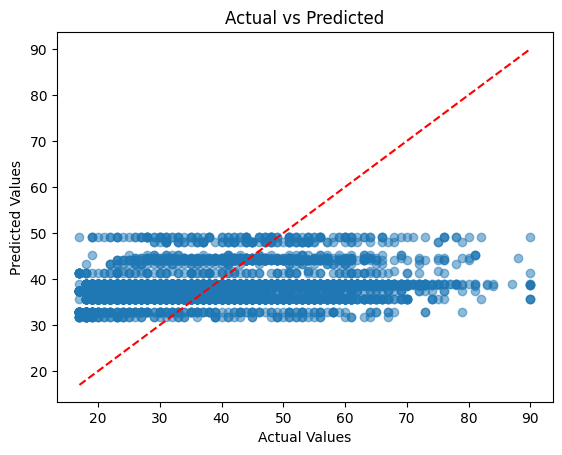

In [43]:
# XGBoost Data Visualisation
import matplotlib.pyplot as plt
import xgboost as xgb
xgb.plot_importance(model)
plt.title("XGBoost Feature Importance")
plt.show()
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Reference line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

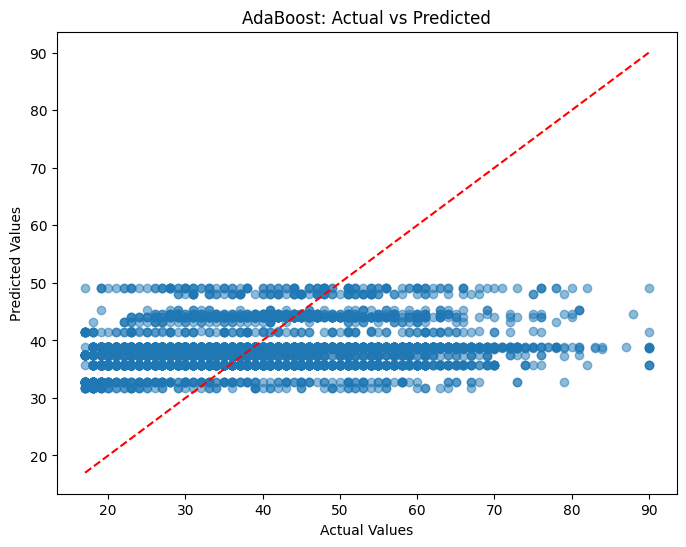

In [44]:
import matplotlib.pyplot as plt

# 1. Plot Actual vs Predicted for AdaBoost
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
# Plot the 45-degree reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("AdaBoost: Actual vs Predicted")
plt.show()